# A coastal flooding study: prediction & sensitivity analysis

Metamodeling course.
O. Roustant, December 2024.

Data kindly provided by the BRGM

*Rohmer, J., Idier, D., Paris, F., Pedreros, R., Louisor, J. (2018). Casting light on forcing and breaching scenarios that lead to marine inundation: Combining numerical simulations with a random forest classification approach. Environmental Modelling & Software, 104, p. 64-80*

We consider the problem of prediction the water height at the site "les Boucholeurs", in the west French coast, given 5 input variables representing weather and earth conditions.

The dataset is composed of 500 flooding maps composed of 194 x 202 pixels, obtained with a design of experiment (DoE) of the 5 input variables. At each pixel, we measure the water height. In addition, for each map, we know the total flooded area. Such maps have been obtained with a time-consuming simulator (1 run $\approx$ 30 minutes to 1 hour). The aim is twofold: 1) to predict a water map for a new configuration in real-time, thus without running the simulator. 2) to quantify the influence of the inputs on water heights, in case of flooding.

For simplicity, we will focus on the subset of data for which there has been flooding, in the sense that the flooding area is non zero, corresponding to 243 maps (see after). The global scheme is the following:
* Split the dataset in a training set Xtrain and a test set Xtest
* PCA encoding: use a PCA analysis to reduce dimension, based on the training set Xtrain
* Create a metamodel on selected principal components, with Xtrain
* Predict the value of the principal components on the test set Xtest
* PCA decoding: reconstitue the map with the PCA eigenvectors

The global sensitivity analysis (GSA) will be done on each principal component. Furthermore, a generalized Sobol index can be defined with the formula:
$$ GSI_I = \frac{\sum_{j = 1}^p \lambda_j S^{(j)}_I}{\sum_{j=1}^p \lambda_j} $$
where $I \subseteq \{1, \dots, d\}$ is a subset of variables, $S^{(j)}_I$ is the corresponding Sobol index of the $j^\textrm{th}$ principal component, and $\lambda_j$ is the $j^\textrm{th}$ eigenvalue.

Here is a brief explanation of the 5 inputs variables:
* Tide (amplitude de la marée), $T \in [0.95m,3.70m]$
* Surge (pic de surcote), $S \in [0.65m,2m]$
* $t_0$ ou $phio$ (Différence de phase entre le pic de surcote et l’amplitude de la marée), phio $\in [-6h, 6h]$
* $tm$ ou $t-$ (Durée de l'augmentation de la surcote), $tm \in [0.5h, 12h]$
* $tM$ ou $t+$ (Durée de la diminution de la surcote), $tM \in [0.5h, 12h]$

Notice that in the dataset, all the input variables have been rescaled to lie in the interval $[0, 1]$.
![Boucholeurs_inputs-2.png](attachment:Boucholeurs_inputs-2.png)

# Starter

1. Load the data and visualize the design of experiments. What kind of design is it? Can you identify it precisely? We color the points whether Area is > 0 (flooding) or not. Can you interpret the flooding zone?


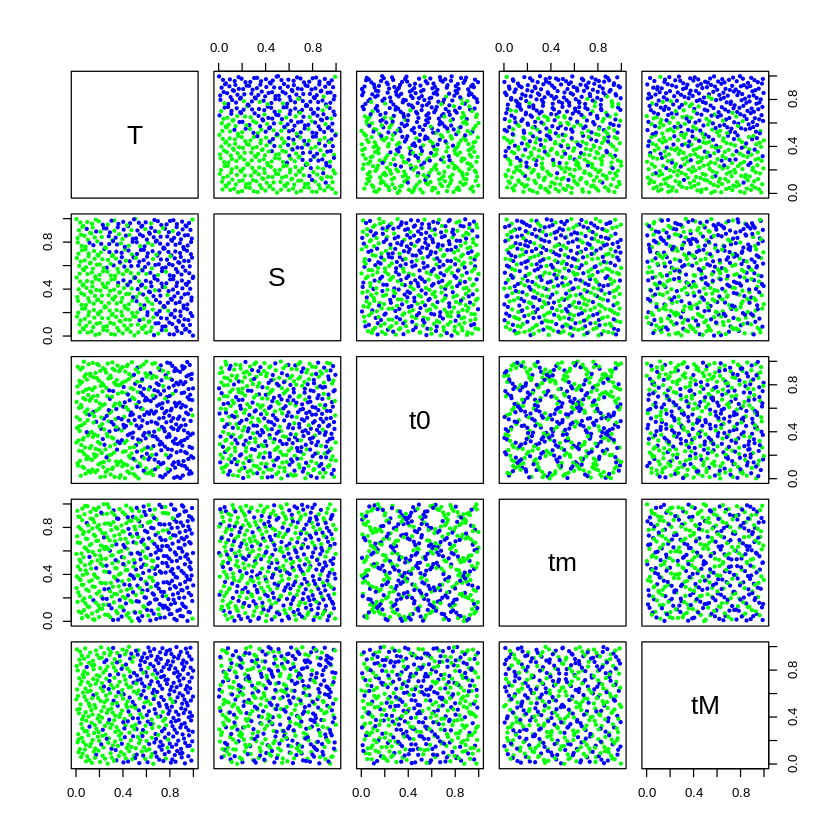

In [1]:
# Question 1 - Data loading and DoE
rm(list = ls())
load("Boucholeurs_NOFailure.RData")

names(doe) <- c("T", "S", "t0", "tm", "tM") # shorter names

doeFull <- doe
HEFull <- HE

# design of experiments, with/without flooding
options(repr.plot.width = 7, repr.plot.height = 7)
pairs(doeFull, pch = 19, cex = 0.5,
      xlim = c(0, 1), ylim = c(0, 1),
      col = ifelse(Area > 0, "blue", "green"))

Loading required package: rngWELL

This is randtoolbox. For an overview, type 'help("randtoolbox")'.



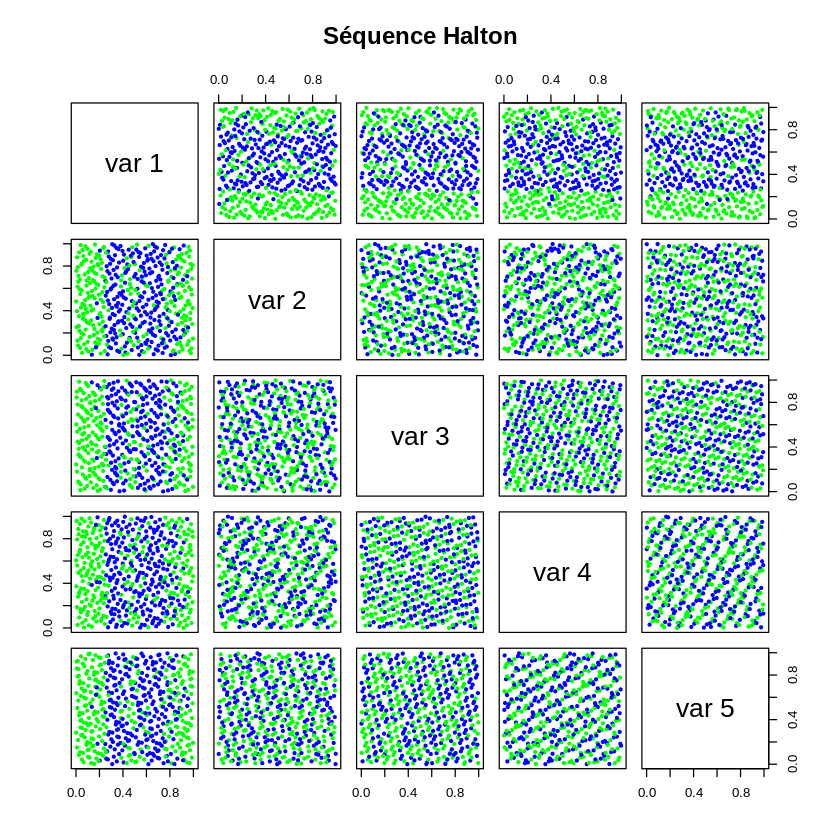

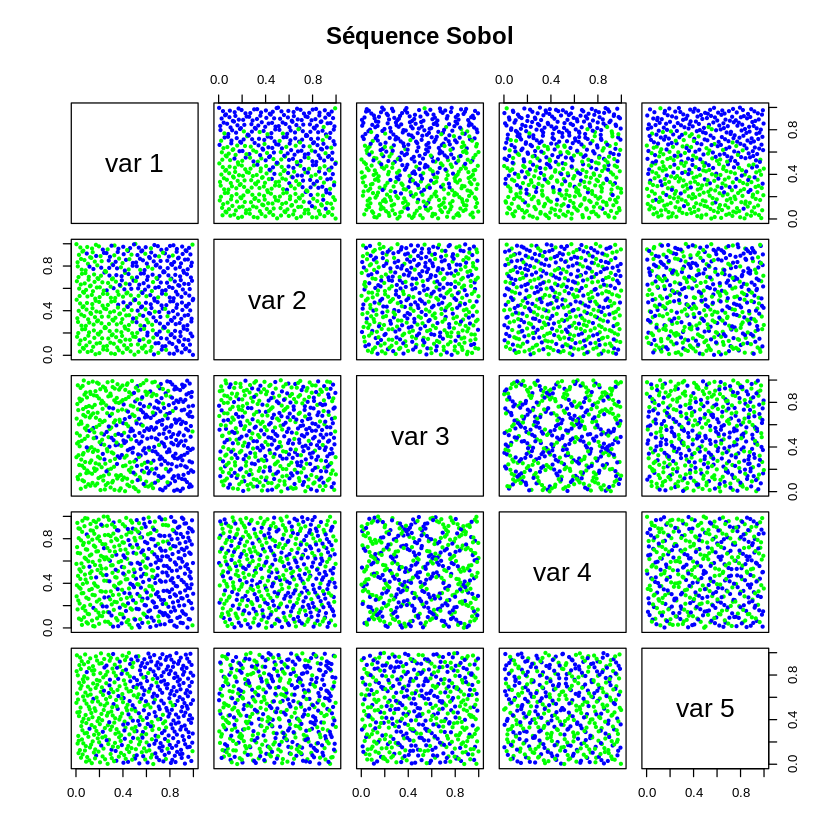

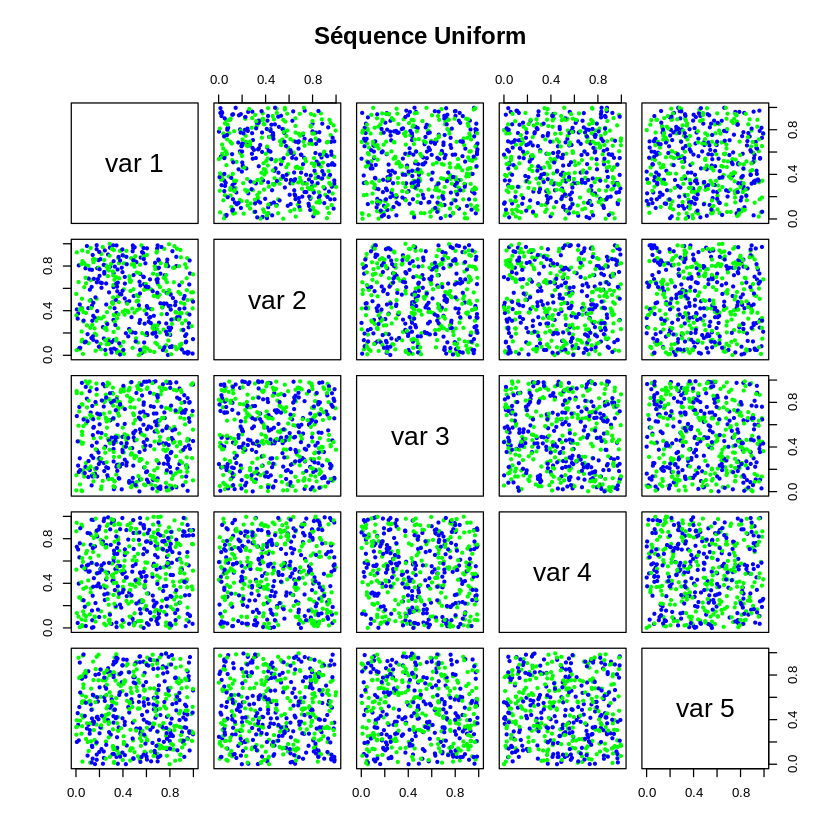

In [6]:
library(randtoolbox)
library(DiceDesign)

# Générer une séquence de Halton correspondant à doeFull
n_points <- nrow(doeFull)  # Nombre de points dans doeFull
n_dims <- ncol(doeFull)    # Nombre de colonnes (dimensions)
halton_seq <- halton(n_points, n_dims)
sobol_seq <- sobol(n_points, n_dims)
uniform_seq <- matrix(runif(n_points * n_dims), nrow = n_points, ncol = n_dims)

options(repr.plot.width = 7, repr.plot.height = 7)
pairs(halton_seq,  pch = 19, cex = 0.5,
      xlim = c(0, 1), ylim = c(0, 1),
      col = ifelse(Area > 0, "blue", "green"), main = "Séquence Halton")

options(repr.plot.width = 7, repr.plot.height = 7)
pairs(sobol_seq,  pch = 19, cex = 0.5,
      xlim = c(0, 1), ylim = c(0, 1),
      col = ifelse(Area > 0, "blue", "green"), main = "Séquence Sobol")

options(repr.plot.width = 7, repr.plot.height = 7)
pairs(uniform_seq,  pch = 19, cex = 0.5,
      xlim = c(0, 1), ylim = c(0, 1),
      col = ifelse(Area > 0, "blue", "green"), main = "Séquence Uniform")

In [7]:

cat("Mindist criterion for the Uniform LDS = ", mindist(uniform_seq), "\n")
cat("Mindist criterion for the Halton LDS = ", mindist(halton_seq), "\n")
cat("Mindist criterion for the Sobol LDS = ", mindist(sobol_seq), "\n")
cat("Mindist criterion for the doeFULL LDS = ", mindist(doeFull), "\n")

Mindist criterion for the Uniform LDS =  0.05154144 
Mindist criterion for the Halton LDS =  0.1273443 
Mindist criterion for the Sobol LDS =  0.1063512 
Mindist criterion for the doeFULL LDS =  0.1063512 


In [10]:
difference <- doeFull - sobol_seq

# Vérifier si toutes les différences sont égales à zéro
all_zero_difference <- all(difference == 0)

# Afficher le résultat
if (all_zero_difference) {
  cat("La différence entre doeFull et Sobol est nulle.\n")
} else {
  cat("La différence entre doeFull et Sobol n'est pas nulle.\n")
}

La différence entre doeFull et Sobol est nulle.


**Response Q1/**

First we plotted the design of uniform sequence, halton sequence and sobol sequence... We then found that it's really similar to the sobol design (which is a space-filling design). Moreover an another way to have an intuition of which design it is, is by comparing the mindist of our doeFULL and the 3 different sequences. Again we find that the mindist of sobol sequence is similar to our mindist for doeFULL. To identify precisely we can now substract the doefull and sobol sequence (making sure they have the same number of points and column) and see if the result is null, which it is. doeFULL is a space-filling design sobol sequence.

We can see that T impact positively if an area is flooded or not (the higher their values, the higher chance for an area to be flooded). Moreover it seems that S only influences positively when interacting with T, else it doesn't. t0 seems to impact the more it's value comes closer to 0.5. Finally tm and tM doesn't seem to have a real impact on wether an area is flooded or not.



From now on, we now work on the design points for which there is flooding. We split the data into train and test sets. For the training set, we create XtrainSet, a matrix of size nTrain x d, and YtrainSet an array containing the images, considered as vectors in dimension D = number of pixels. Idem for the test set.

2. Visualize the maps of the training set corresponding to the given subsample of 4 design points (and check that there is indeed a flooding in some zone).  

Loading required package: spam

Spam version 2.11-0 (2024-10-03) is loaded.
Type 'help( Spam)' or 'demo( spam)' for a short introduction 
and overview of this package.
Help for individual functions is also obtained by adding the
suffix '.spam' to the function name, e.g. 'help( chol.spam)'.


Attaching package: ‘spam’


The following objects are masked from ‘package:base’:

    backsolve, forwardsolve


Loading required package: viridisLite


Try help(fields) to get started.



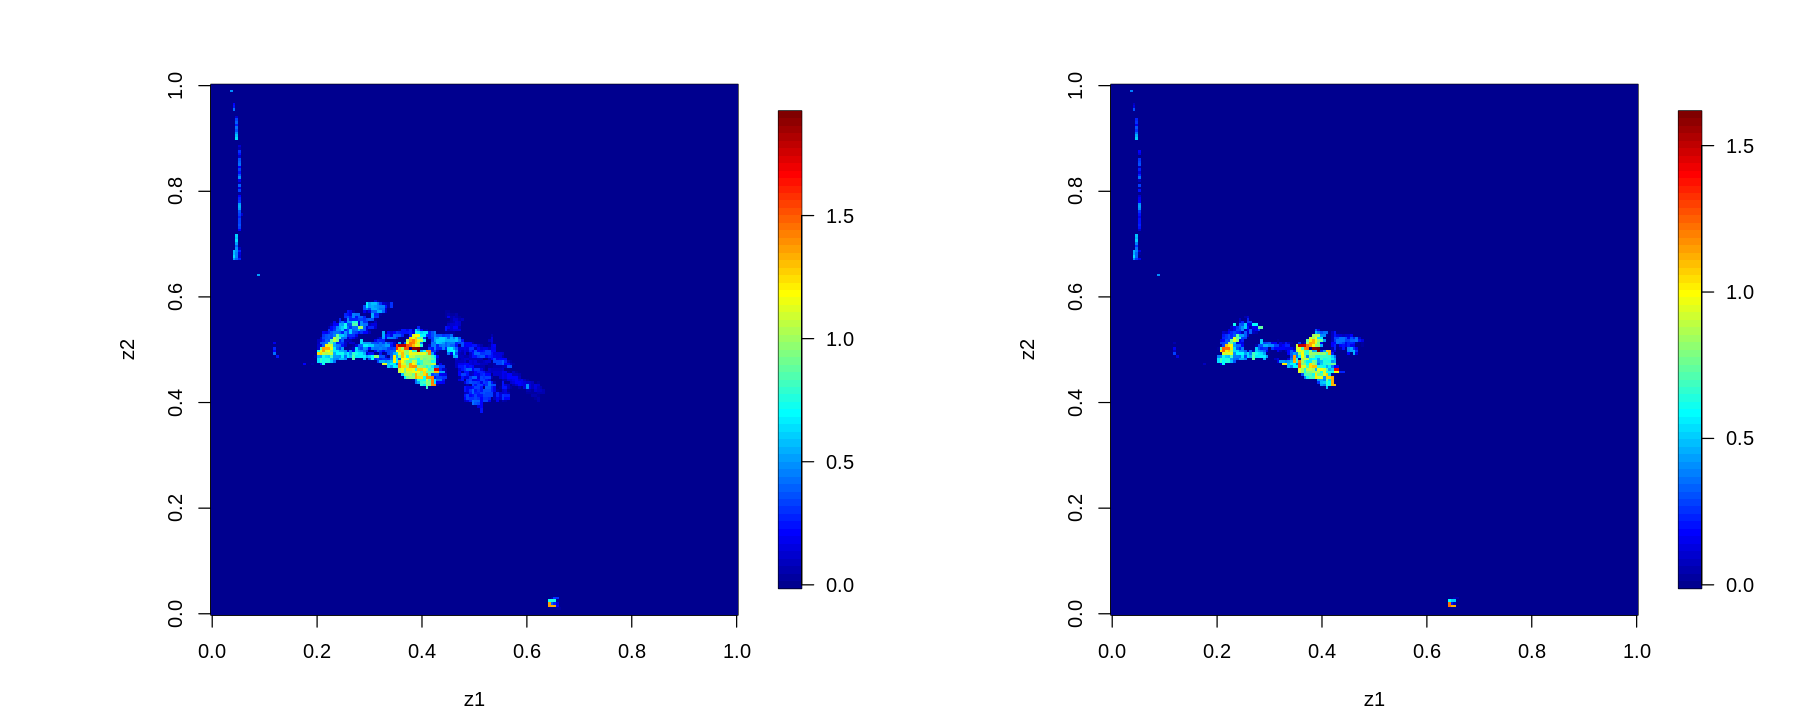

In [11]:
# In the sequel, we consider the subset of the DoE for which there has been flooding
inondOnly <- which(Area > 0)
doe <- doeFull[inondOnly, ]
HE <- HEFull[, , inondOnly]

# Utilities and maps visualization
# Map visualizations.
library(fields)

nGridx <- dim(HE)[1]
nGridy <- dim(HE)[2]

map2vec <- function(map){
  as.numeric(map)
}
vec2map <- function(vec, nx = nGridx, ny = nGridy){
  matrix(vec, nrow = nx, ncol = ny)
}

z1 <- seq(from = 0, to = 1, length = nGridx)
z2 <- seq(from = 0, to = 1, length = nGridy)

par(mfrow = c(1, 2))
options(repr.plot.width = 15, repr.plot.height = 6)
for (i in 1:2){
  image.plot(z1, z2, HE[,,i], graphics.reset = TRUE)
}

In [15]:
# train and test set
n <- nrow(doe)
nTrain <- 150
nTest <- n - nTrain
set.seed(0)
indTrain <- sample(1:n, size = nTrain)
indTest <- setdiff(1:n, indTrain)

Xtrain <- doe[indTrain, ]
Xtest <- doe[-indTrain, ]

YtrainSet <- matrix(NA, nrow = nTrain, ncol = nGridx * nGridy)
YtestSet <- matrix(NA, nrow = nTest, ncol = nGridx * nGridy)

for (i in 1:nTrain){
  YtrainSet[i, ] <- map2vec(HE[, , indTrain[i]])
}
for (i in 1:nTest){
  YtestSet[i, ] <- map2vec(HE[, , indTest[i]])
}


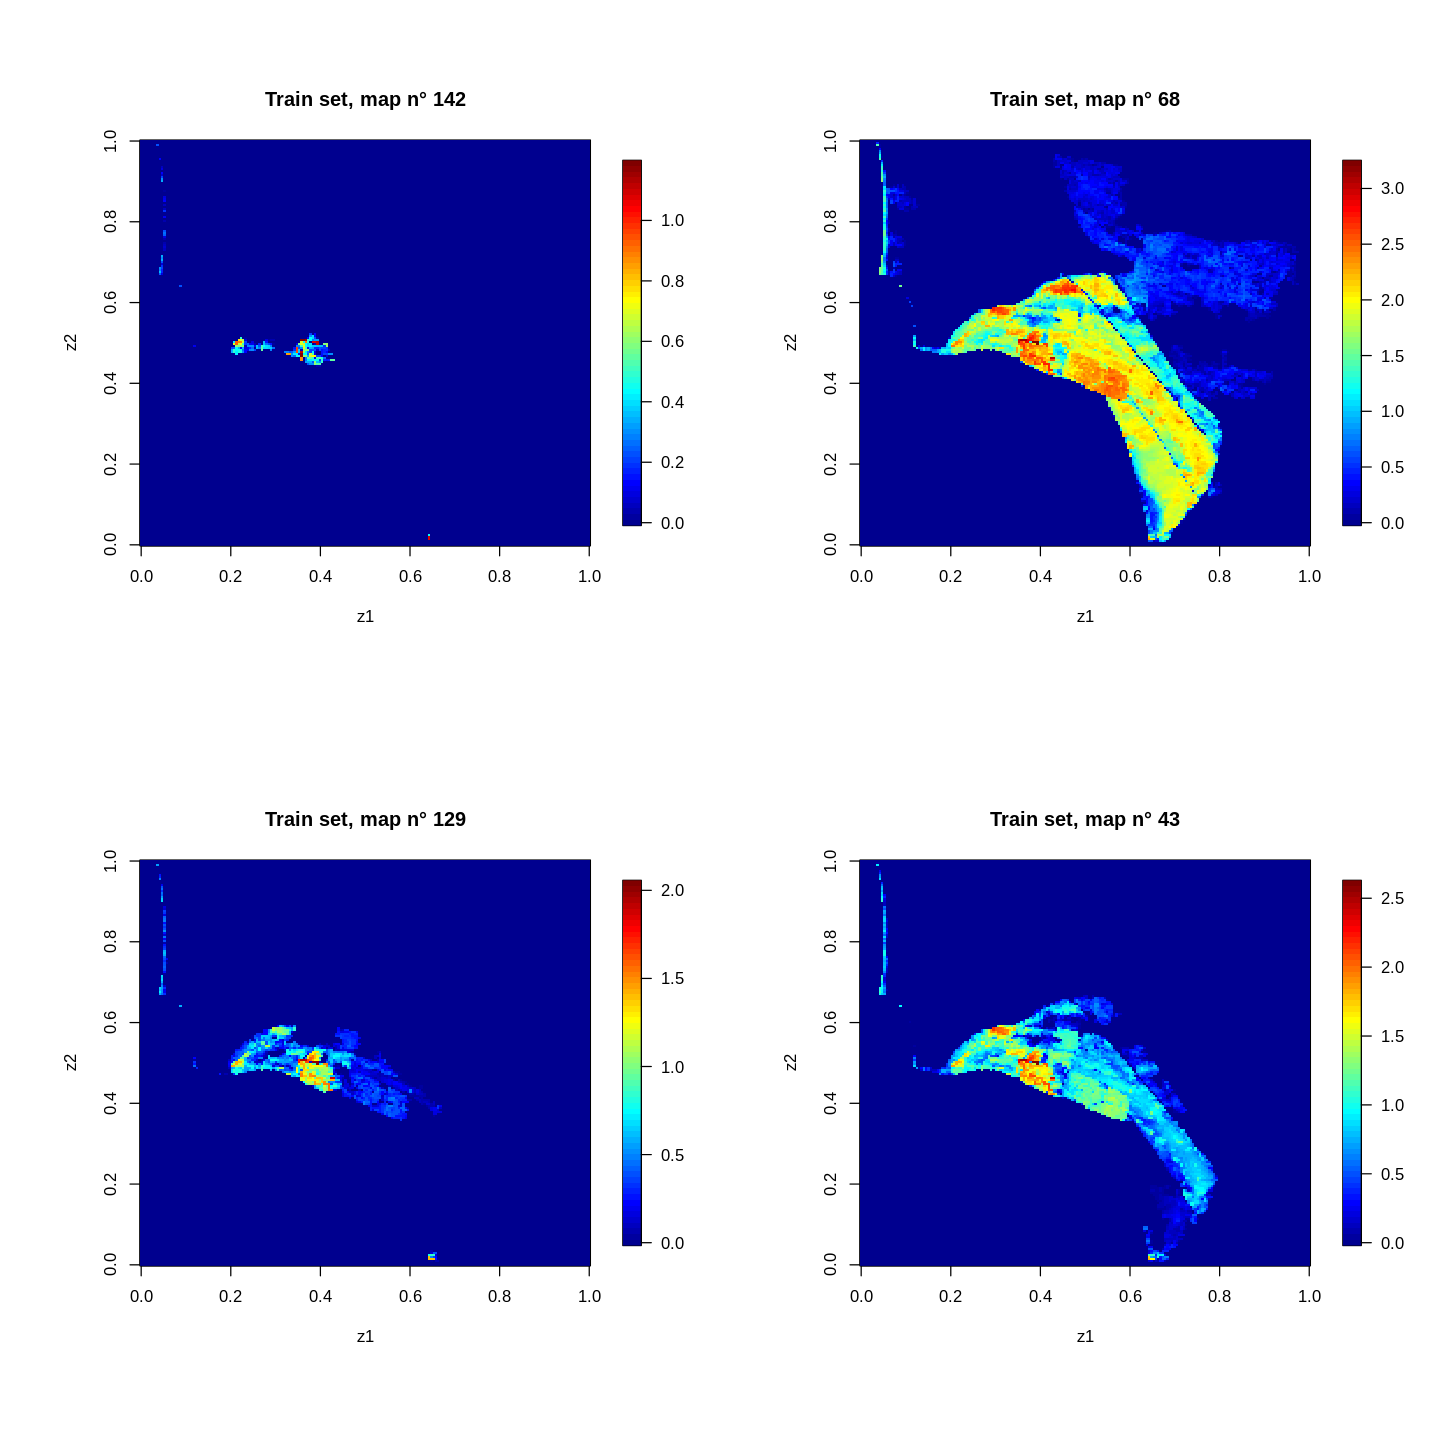

In [16]:
# Question 2
set.seed(0)
subsample <- sample(1:nTrain, 4)

par(mfrow = c(2, 2))
options(repr.plot.width = 12, repr.plot.height = 12)
for (i in 1:4){
  j <- subsample[i]
  image.plot(z1, z2, vec2map(YtrainSet[j, ]),    # map of the training set n°j
             main = paste("Train set, map n°", j),
             graphics.reset = TRUE)
}


**Response Q2/**

We can indeed see that some zone are flooded with at most 3m of water

3. Do a principal components analysis (PCA) on the training set, without scaling the data (here it seems to work better). How many principal components seem useful? How should we select them in a machine learning framework (we will not do it here)? Visualize the first four principal components (PCs) as a map. Interpret them by remembering that a PC is a linear combination of the original variables.

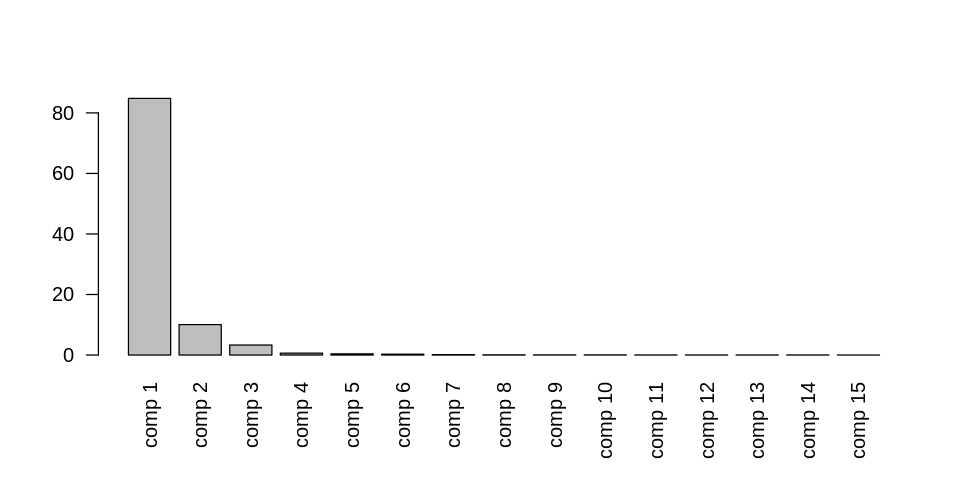

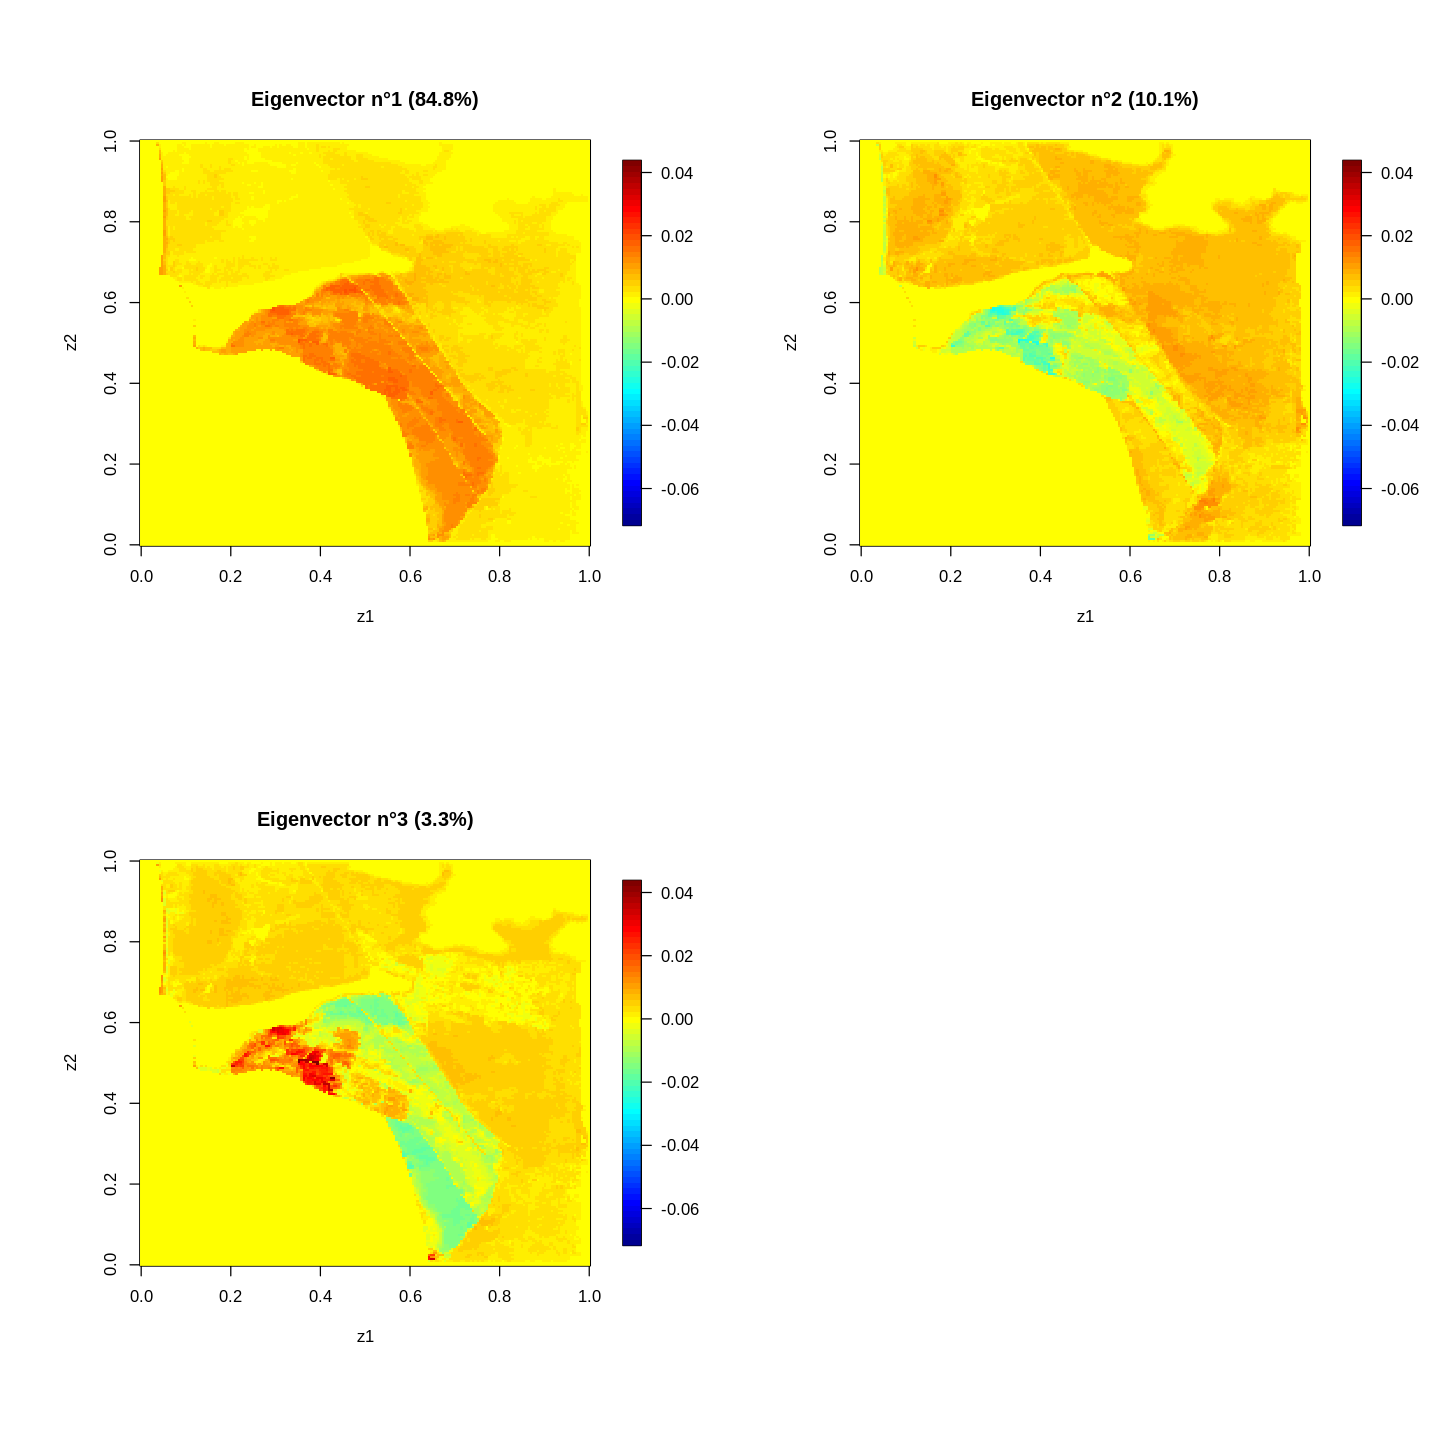

In [18]:
# Question 3
# PCA on trainSet
library(FactoMineR)

resPCA <- PCA(YtrainSet, graph = FALSE,     # PCA on the maps of the training set
              scale.unit = FALSE, ncp = 20)

par(mfrow = c(1, 1))
options(repr.plot.width = 8, repr.plot.height = 4)
barplot(resPCA$eig[1:15, 2], las = 2)

# visualization of the first eigenvectors, as maps
par(mfrow = c(2, 2))
options(repr.plot.width = 12, repr.plot.height = 12)
zlim = range(resPCA$svd$V[, 1:4])
for (j in 1:3){
  image.plot(z1, z2, vec2map(resPCA$svd$V[, j]),
             zlim = zlim,
             main = paste("Eigenvector n°", j, " (",
                          round(resPCA$eig[j, 2], 1),  "%)", sep = ""),
             graphics.reset = TRUE)
}


**Response Q3/**

The first comp explains more than 80% of the information (of the total variation to be more precise) so only the first comp seem useful.

In a machine learning framework, the principal components (PCs) are selected based on their ability to explain variance in the data.

Each PC has an eigenvalue that represents the variance it explains in the dataset. The explained variance ratio is the percentage of variance explained by each PC. Moreover each PC is a linear combination of the original variables. Here the color intensity shows the weight of the orignal variable in a certain area, and the positive and negative values (red and blue) show how different regions contribute to each PC.

So if we interpret the first PC for exemple, it should represent a global trend or a dominant factor that's affecting the entire dataset as we can see that all the map is affected. (85% show that the PC captures the most dominant spatial pattern in the data.)

PC2 explains the next largest source of variance. There's less area affected so it may capture regional differences or contrasts within the data.

PC3 explains much less variance compared to PC1 and PC2. It likely represents smaller-scale structures or noise.

4. We provide a PCA encoder that takes a map (viewed as a vector in dimension D) and builds all principal components. Similarly, we provide a PCA decoder that takes a number of PCs and reconstitute the map (the vector in dimension D). For verification, choose a map. Apply the PCA encoder, and the PCA decoder with $n_{PC} = 10$ PCs. Check that you reconstitue well the original map.


[1] 5.270486e-24

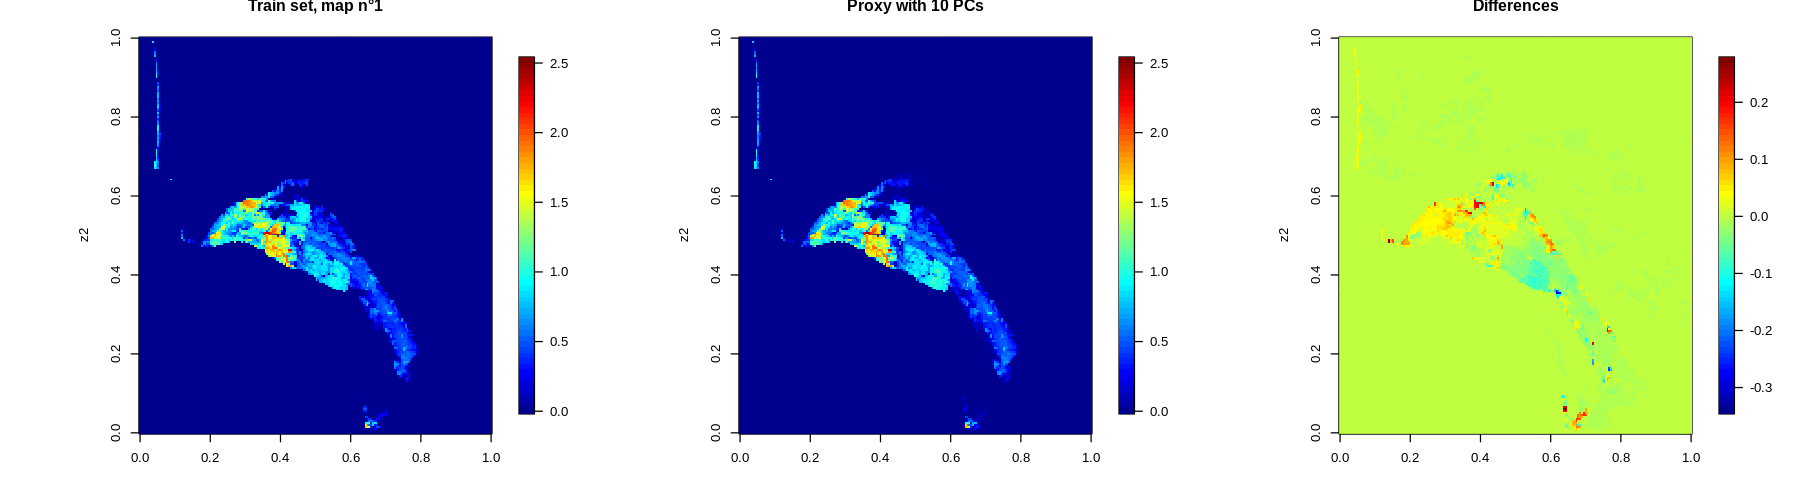

In [20]:
# Question 4
PCAencoder <- function(dataset, PCAmodel){
  # takes a dataset whose rows are vector in R^p and returns the PC coordinates
  # notice that the vector is first centered and scaled (if scale.unit = TRUE in PCAmodel)
  vect <- scale(dataset,
                center = PCAmodel$call$centre,
                scale = PCAmodel$call$ecart.type)
  return(vect %*% PCAmodel$svd$V)
}

# test for PCAencoder
PCcoord <- PCAencoder(YtrainSet, PCAmodel = resPCA)
sum((resPCA$ind$coord - PCcoord)^2)  # should be zero

PCAdecoder <- function(PCcoord, PCAmodel){
  # takes a matrix whose rows are PC coordinates
  # and express it in the original space R^q
  # notice that data are scaled back and centered back
  nPC <- ncol(PCcoord)
  res <- PCcoord %*% t(PCAmodel$svd$V[, 1:nPC])
  for (i in 1:nrow(res)){
    res[i, ] <- res[i, ] * PCAmodel$call$ecart.type + PCAmodel$call$centre
  }
  # here the result should be non-negative
  res <- pmax(res, 0)
  return(res)
}

# compute PC coordinates (apply the PCA encoder)
PCcoord <- PCAencoder(YtrainSet, resPCA)
# reconstitute the images from the first nPC coordinates (apply the PCA decoder)
nPC <- 10
YtrainSetProxy <- PCAdecoder(PCcoord[,1:nPC], resPCA)

# test
par(mfrow = c(1, 3))
options(repr.plot.width = 15, repr.plot.height = 4)
zlim <- range(c(YtrainSet[1, ], YtrainSetProxy[1, ]))
image.plot(z1, z2, zlim = zlim, vec2map(YtrainSet[1, ]),
           main = "Train set, map n°1",
           graphics.reset = TRUE)
image.plot(z1, z2, zlim = zlim, vec2map(YtrainSetProxy[1, ]),
           main = paste("Proxy with", nPC, "PCs"),
           graphics.reset = TRUE)
image.plot(z1, z2, vec2map(YtrainSet[1, ] - YtrainSetProxy[1, ]),
           main = paste("Differences"),
           graphics.reset = TRUE)


**Response Q4/**

The reconstruction is accurate as observed from the figures: the proxy map (middle) closely resembles the original map (left), capturing the key patterns,        
 shapes and levels . The difference map (right) highlights only small and localized deviations, with most areas being close to zero (green), indicating minimal reconstruction error.
 The deviations are minor in magnitude, as shown by the difference scale ranging from approximately -0.3 to 0.3, which is small compared to the original data range (0 to 2.5).

 This confirms that using 10 principal components preserves the overall structure and details of the original data effectively.

5. Estimate a kriging (= GP) model for each of the first 10 PCs. What kernel is used by default? Recall why we must use a $\texttt{multistart}$ in the hyperparameter estimation (here choose $\texttt{multistart = 50}$). Consider the 1st PC. Look at the estimated coefficients of the kernel, and explain why we can detect here the most influential variables. Study the validity of the model (function 'plot'). What's happening for the PC with order $\geq 4$? Is it a problem for the final prediction?

Loading required package: foreach

Loading required package: doParallel

Loading required package: iterators

Loading required package: parallel




optimisation start
------------------
* estimation method   : MLE 
* optimisation method : BFGS 
* analytical gradient : used
* trend model : ~1
* covariance model : 
  - type :  matern5_2 
  - nugget : NO
  - parameters lower bounds :  1e-10 1e-10 1e-10 1e-10 1e-10 
  - parameters upper bounds :  1.8125 1.972656 1.964844 1.976562 1.980469 
  - best initial criterion value(s) :  -631.7748 -642.4105 -653.2486 -665.2105 -669.4121 -686.7555 -691.1419 -694.3887 -695.1599 -695.6791 -702.2331 -703.9092 -704.4663 -711.0811 -716.9168 -720.9244 -732.5283 -732.6917 -733.7813 -741.4654 -742.3296 -742.7246 -743.1153 -743.5764 -747.3198 -748.1333 -752.9177 -757.7916 -759.7134 -759.8513 -760.6196 -764.2176 -770.7217 -772.1399 -774.6188 -778.1626 -785.2071 -787.3838 -791.9238 -794.162 -794.6298 -795.2419 -799.5628 -806.1262 -806.1458 -807.509 -809.7818 -811.0931 -830.7225 -843.5691 


* The 50 best values (multistart) obtained are:
 614.2168 614.2168 614.2168 614.2168 614.2168 614.2168 614.2168 614.

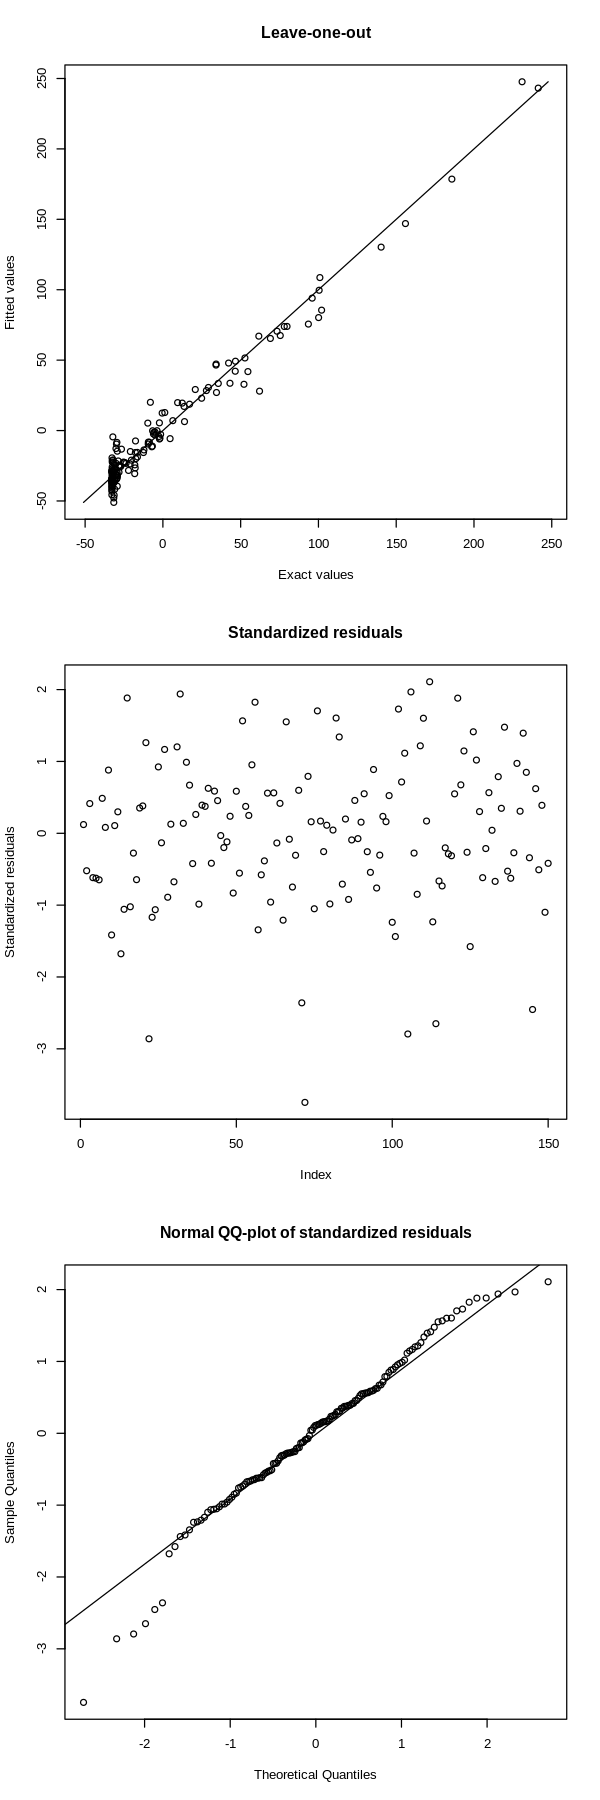

In [24]:
# Question 5
GPlist <- list()  # the GP models for each selected PCsgbgt will be stored in this list

library(DiceKriging)
require(foreach)

# fit a kriging model for the first nPC principal components
require(doParallel)
nCores <- detectCores() - 1
cl <-  makeCluster(nCores)
registerDoParallel(cl)

nPC <- 10 # just to start: to be increased !!!
for (j in 1:nPC){
  GPlist[[j]] <- km(design = Xtrain, response = PCcoord[,j],
                    multistart = 50)
} # pC coord c'est les coordonnée de

stopCluster(cl)

# print results
print(GPlist[[1]])  # example for the first GP model

# quality of GP models
options(repr.plot.width = 5, repr.plot.height = 15)
plot(GPlist[[1]])

**Response Q5/**

* The default kernel used in the DiceKriging package for Gaussian Process (GP) models is the **Matérn 5/2 kernel (matern5_2)**, which provides a good balance between smoothness and flexibility by assuming the function is twice differentiable.

The Matérn 5/2 kernel is defined as:


$$
k(x, x') = \sigma^2 \left( 1 + \frac{\sqrt{5} \| x - x' \|}{\theta} + \frac{5 \| x - x' \|^2}{3 \theta^2} \right) \exp\left( -\frac{\sqrt{5} \| x - x' \|}{\theta} \right)
$$

where:  
$x$ and $x'$: Input points.  
$\| x - x' \|$: Euclidean distance between $x$ and $x'$.  
$\theta$: Length-scale parameter controlling the smoothness of the function.  
$\sigma^2$: Variance (amplitude) parameter.  

*  The multistart is an optional integer that specifies the number of initial starting points for the BFGS optimizer.
 When fitting GP models for the first 10 principal components (PCs), the multistart parameter is set to 50 to ensure robust hyperparameter estimation. This is necessary because the likelihood function is non-convex and can have multiple local minima. By initializing the optimization process from 50 random starting points, the chances of finding the global minimum are increased, ensuring better accuracy and stability of the fitted GP models.

* For the 1st principal component (PC1), the estimated coefficients of the **Matérn 5/2 kernel** (length-scale parameters $\theta$) allow us to identify the most    influential variables. A **small length-scale** indicates that the model is highly sensitive to changes in that variable, meaning it has a strong influence on the output.In this case, $t_0$ has the **smallest length-scale** ($\theta = 0.2916$), making it the **most influential variable**, as small changes in $t_0$ lead to significant variations in PC1. Similarly, $T$, with a relatively small length-scale ($\theta = 0.5423$), is also influential. Conversely, variables with larger length-scales, such as $t_m$ and $t_M$, have less impact, as the model's predictions remain smoother when these variables change.
Thus, the kernel coefficients reveal the variables that contribute most to the variability captured by PC1.
* The diagnostic plots confirm the validity of the Gaussian Process model for the 1st principal component (PC1). The **Leave-One-Out plot** shows that the fitted values align closely with the exact values, indicating strong predictive accuracy. The **standardized residuals plot** demonstrates that the residuals are randomly distributed around zero, with no visible patterns, suggesting the model is unbiased. Finally, the **Normal QQ-plot** shows that the residuals are approximately normally distributed, with minor deviations in the tails. Overall, the model is reliable and effectively captures the variability in PC1.
* For PC4, the Gaussian Process model shows reduced accuracy compared to earlier PCs. The kernel coefficients reveal very **small length-scales** for  $t_0$ ($\theta = 0.0384$) and $t_m$  ($\theta = 0.0205$), indicating that the model is highly sensitive to these variables. However, the **Leave-One-Out plot** shows significant deviations from the diagonal, suggesting poor predictive performance. The **standardized residuals** display greater dispersion, and the **Normal QQ-plot** indicates deviations from normality, especially in the tails.  
This behavior occurs because higher-order PCs, like PC4, explain less variance and are dominated by noise, making them harder to model accurately. For PCs with order great or equal than 4, these inaccuracies are common but **not problematic for the final prediction**, as higher-order PCs contribute minimally to the overall variance of the data.



6. Compute the predictions on the test set, by computing the predictions of each GP and use the PCA decoder.  Choose a map of the test set. Visualize the predicted map and compare. We visualize the spatial errors over all the test set $T$, defined by
$$ \text{RMSE} = \left( \frac{1}{\vert T \vert} \sum_{i \in T} \Vert Y_i - \hat{Y}_i \Vert^2 \right)^{1/2}$$
where $Y_i$ is a map (D dim. vector) and $\hat{Y}_i$ is the predicted map. Comment the results.
We also compute the $Q^2$ criterion defined by
$$ Q^2 = 1 - \sum_{i \in T} \frac{\Vert Y_i - \hat{Y}_i \Vert^2}{\Vert Y_i - \bar{Y} \Vert^2}$$
where $\bar{Y}$ is the 'mean map' obtained by averaging over all maps (in the test set). Thus the $Q^2$ is equal to 1 if the prediction is perfect, 0 if it is as good as the mean, negative if worse.

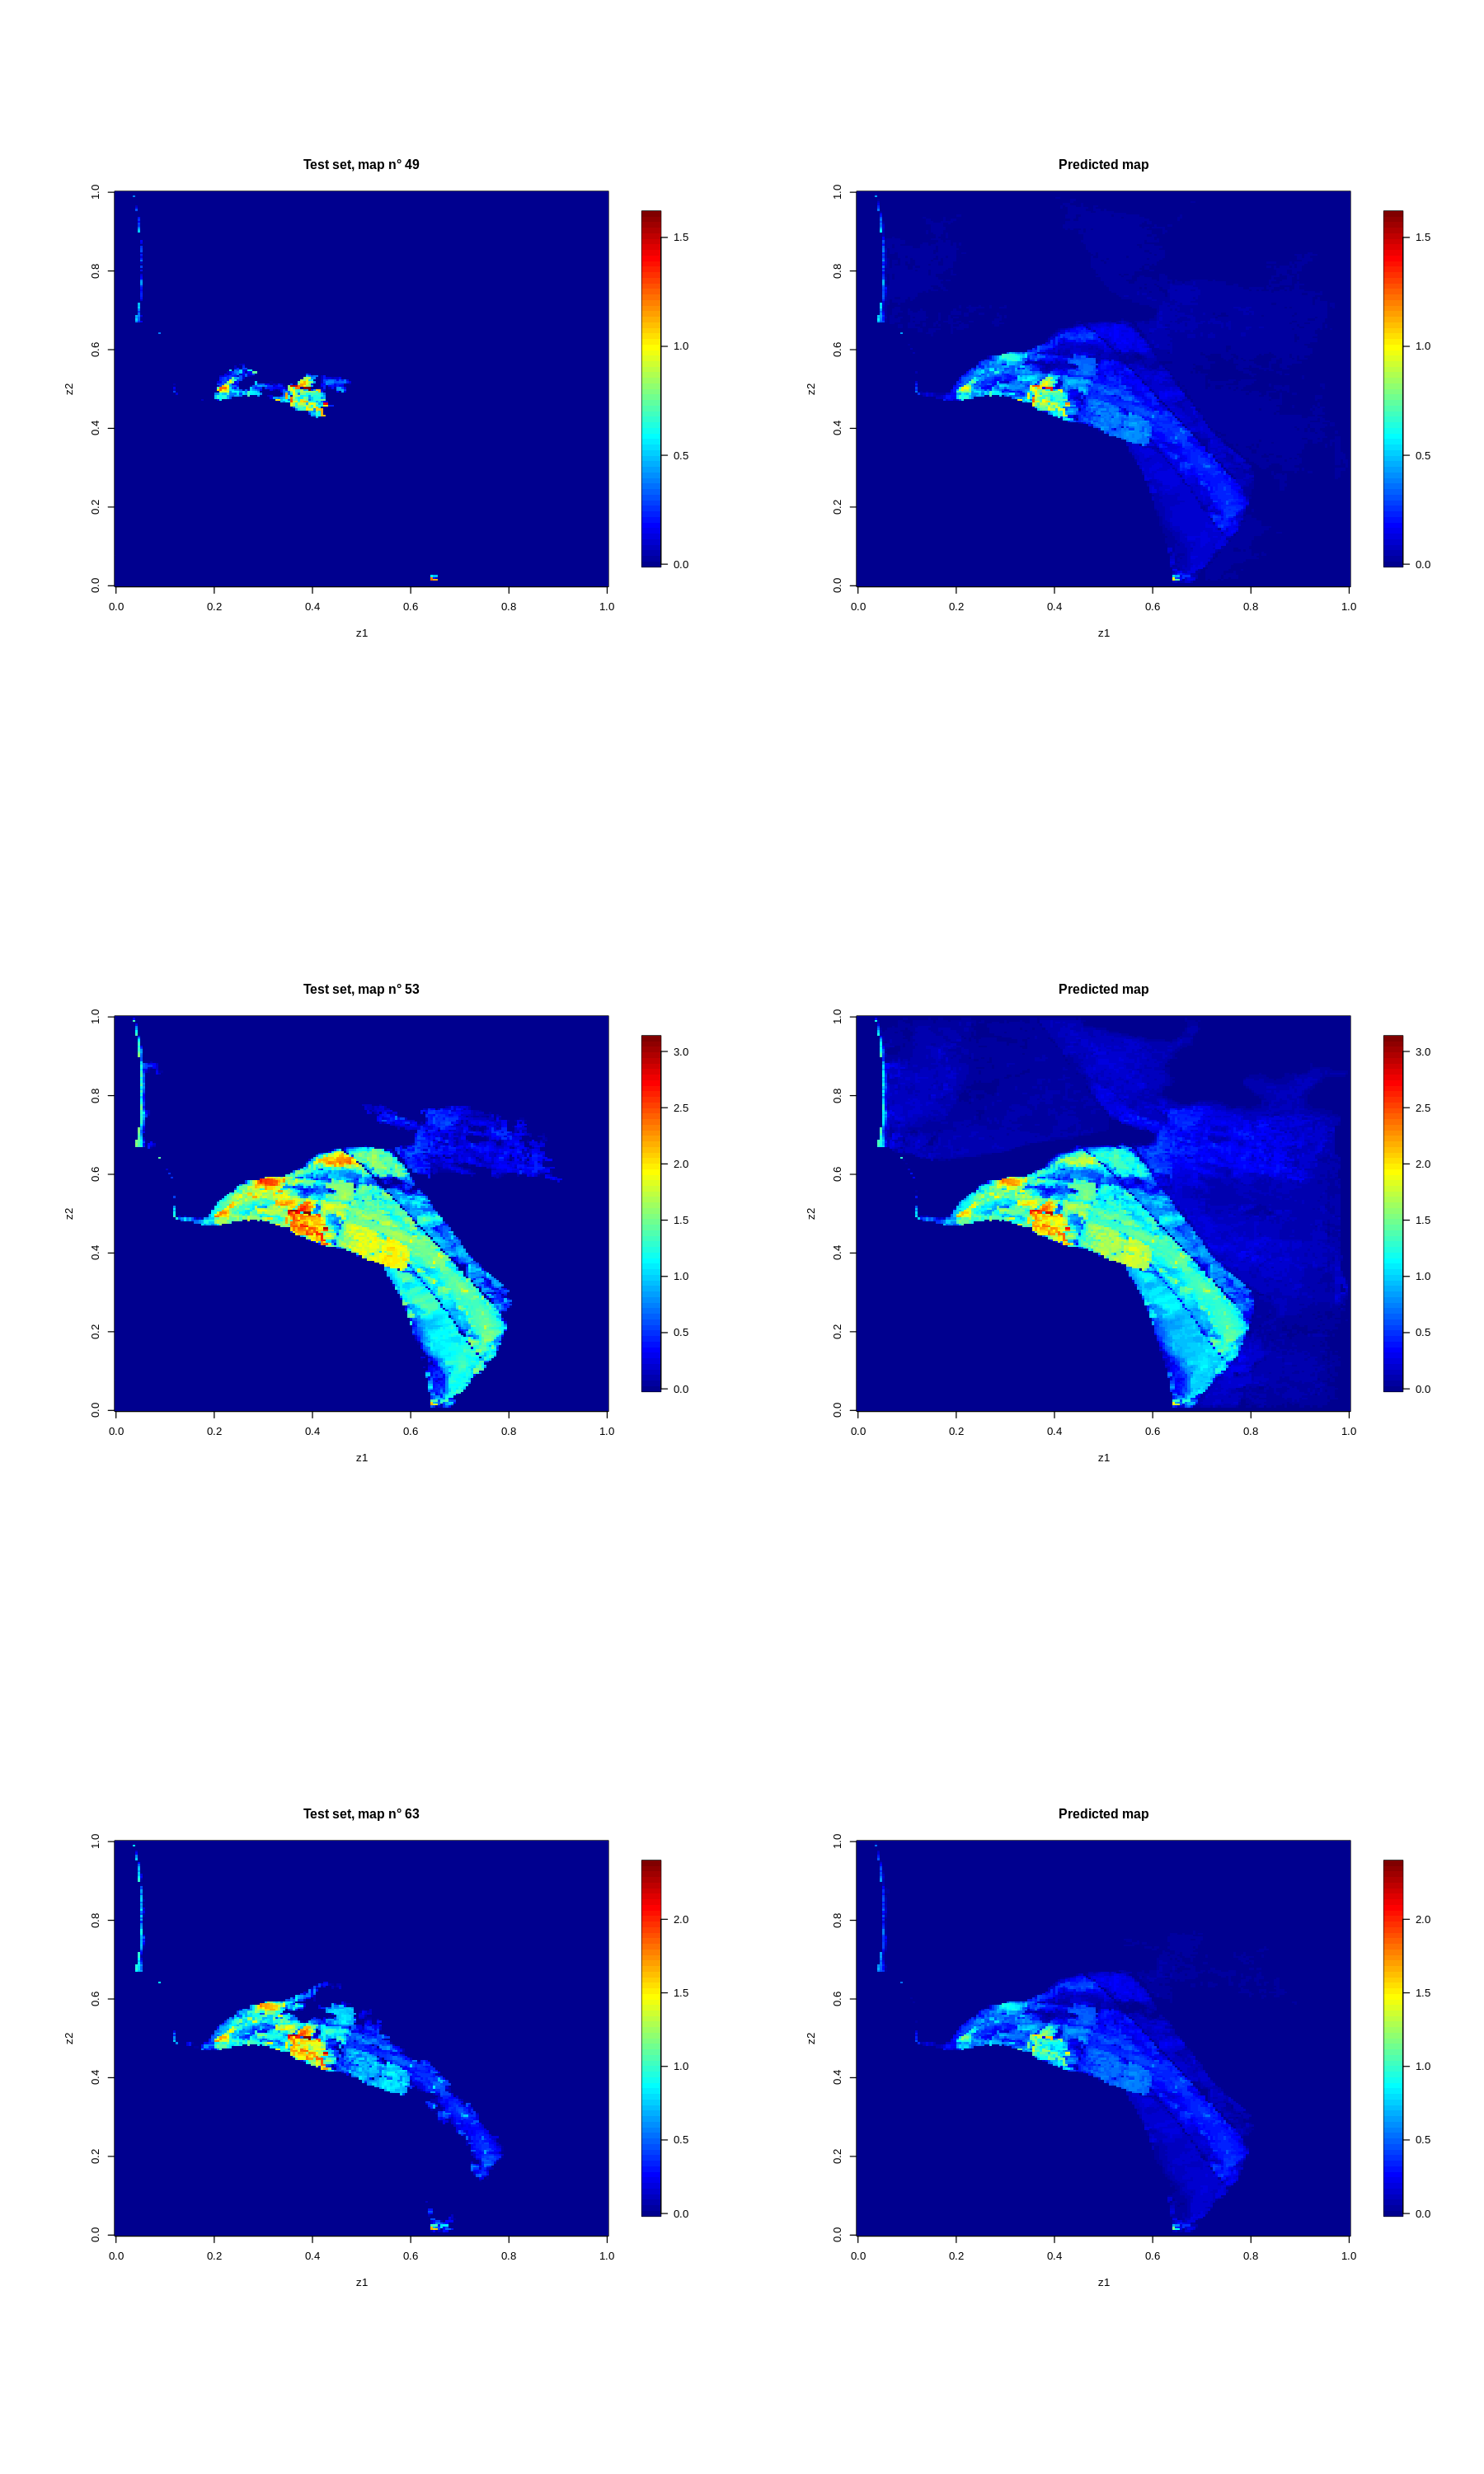

In [25]:
# question 6
# compute predictions
GPpred <- matrix(NA, nrow = nTest, ncol = nPC)
for (j in 1:nPC){
    # prediction for each PC
    GPpred[, j] <- predict(GPlist[[j]], newdata = Xtest
    ,
                           checkNames = FALSE, type = "UK")$mean
}

# deduce the prediction on the image with the PCA decoder
YtestSetGPpred <- PCAdecoder(GPpred, resPCA)


# test
par(mfrow = c(3, 2))
options(repr.plot.width = 15, repr.plot.height = 25)
for (i in 1:3){
  j <- sample(1:nTest, 1)
  zlim <- range(c(YtestSet[j, ], YtestSetGPpred[j, ]))
  image.plot(z1, z2, zlim = zlim, vec2map(YtestSet[j, ]),
             main = paste("Test set, map n°", j),
             graphics.reset = TRUE)
  image.plot(z1, z2, zlim = zlim, vec2map(YtestSetGPpred[j, ]),
             main = "Predicted map",
             graphics.reset = TRUE)
}


Q2 =  0.9488348 


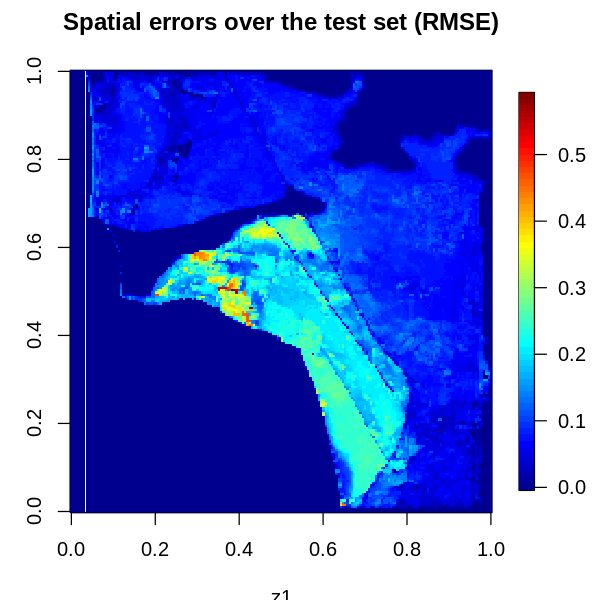

In [26]:
# Question 6 (continued)
# computation of the spatial error
spatialMSE <- function(obs, pred){
  colMeans((obs - pred)^2)
}

RMSE <- sqrt(spatialMSE(YtestSet, YtestSetGPpred))
par(mfrow = c(1, 1))
options(repr.plot.width = 5, repr.plot.height = 5)
image.plot(z1, z2, zlim = c(0, max(RMSE)),
           matrix(RMSE, nrow = nGridx, ncol = nGridy),
           main = "Spatial errors over the test set (RMSE)",
           graphics.reset = TRUE)

Q2 <- function(obs, pred){
  sampleMean <- colMeans(obs) # naive prediction by the sample mean
  Q2num <- mean(spatialMSE(obs, pred))
  Q2denum <- mean(spatialMSE(obs, sampleMean))
  return(1 - Q2num / Q2denum)
}

cat("Q2 = ", Q2(YtestSet, YtestSetGPpred), "\n")


**Response Q6/**

* The model's performance is excellent, as reflected by a  $Q^2$ value of **0.9485**, demonstrating that the predictions are highly accurate and close to the true maps.  From the RMSE heatmap, most regions display small errors (blue shades), confirming the model's reliability. However, a few localized areas show slightly higher errors (yellow/red shades), particularly around complex spatial features, where fine-scale variations are harder to capture. Despite these localized discrepancies, the Gaussian Process model combined with PCA decoding effectively reconstructs the spatial maps, capturing the dominant patterns with minimal overall error.


7. Let us consider the first PC. We do a GSA on the kriging mean. Estimate numerically the Sobol indices and total indices, using the function $\texttt{soboljansen}$ (R package $\texttt{sensitivity}$). What are the most influential inputs? The inactive ones? Are there interactions? Between which variables? Why can we deduce that there are no interactions of order 4 or 5 here? Same questions for the second PC.

In [30]:
#Question 7
# Packages nécessaires
library(sensitivity)
library(ggplot2)
library(reshape2)

# Simulation
N <- 30000 # Taille de l'échantillon
d <- ncol(doe) # Nombre de variables
X1 <- matrix(runif(N * d, min = 0, max = 1), nrow = N, ncol = d)
X2 <- matrix(runif(N * d, min = 0, max = 1), nrow = N, ncol = d)
X1 <- data.frame(X1); names(X1) <- names(doe)
X2 <- data.frame(X2); names(X2) <- names(doe)

# Analyse de sensibilité pour les 2 premières composantes principales
nPC_for_SA <- 2

# Fonction prédictive pour le krigeage
krigingMean <- function(Xnew, m) {
  predict.km(m, Xnew, "UK", se.compute = FALSE, checkNames = FALSE)$mean
}
mySA_GP1 = list()
# Matrices pour stocker les résultats
sobolIndexGP <- matrix(NA, nrow = nPC_for_SA, ncol = d)
totalIndexGP <- matrix(NA, nrow = nPC_for_SA, ncol = d)
colnames(sobolIndexGP) <- colnames(totalIndexGP) <- names(doe)

# Calcul des indices pour chaque composante principale
for (j in 1:nPC_for_SA) {
  mySA_GP1 <- soboljansen(
    model = krigingMean,
    X1 = X1, X2 = X2,
    nboot = 100,
    m = GPlist[[j]]
  )
  totalIndexGP[j, ] <- mySA_GP1$T$original
  sobolIndexGP[j, ] <- mySA_GP1$S$original
     # Identification des variables influentes et des interactions
  influential_vars <- colnames(sobolIndexGP)[which(totalIndexGP[j, ] > 0.1)]
  inactive_vars <- colnames(sobolIndexGP)[which(totalIndexGP[j, ] < 0.1)]


  # Impression des réponses pour chaque PC
  cat("\n### Results for Principal Component (PC)", j, "###\n")
  cat("First-order Sobol Indices:\n")
  print(sobolIndexGP[j, ])

  cat("\nTotal Sobol Indices:\n")
  print(totalIndexGP[j, ])

  cat("\nInfluential Variables (Indices > 0.1):\n")
  print(influential_vars)

  cat("\nInactive Variables (Indices < 0.01):\n")
  print(inactive_vars)


}

Registered S3 method overwritten by 'sensitivity':
  method    from 
  print.src dplyr


Attaching package: ‘sensitivity’


The following object is masked from ‘package:randtoolbox’:

    sobol





### Results for Principal Component (PC) 1 ###
First-order Sobol Indices:
          T           S          t0          tm          tM 
0.226438174 0.028895374 0.083226560 0.002971795 0.007275379 

Total Sobol Indices:
         T          S         t0         tm         tM 
0.76231267 0.45171324 0.43769443 0.06151234 0.06453965 

Influential Variables (Indices > 0.1):
[1] "T"  "S"  "t0"

Inactive Variables (Indices < 0.01):
[1] "tm" "tM"

### Results for Principal Component (PC) 2 ###
First-order Sobol Indices:
            T             S            t0            tm            tM 
 0.1359750059 -0.0182460349  0.0371075707 -0.0019372391 -0.0007299665 

Total Sobol Indices:
         T          S         t0         tm         tM 
0.86340345 0.63849515 0.49660165 0.04707672 0.07982063 

Influential Variables (Indices > 0.1):
[1] "T"  "S"  "t0"

Inactive Variables (Indices < 0.01):
[1] "tm" "tM"


In [31]:
mySA_GP1$S

,original,bias,std. error,min. c.i.,max. c.i.
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
T,0.1359750059,0.0030823597,0.01681089,0.094190197,0.16636428
S,-0.0182460349,0.0012070374,0.01618253,-0.050539012,0.01136691
t0,0.0371075707,-0.0004662780,0.01653980,0.004139983,0.07303342
tm,-0.0019372391,0.0012909131,0.01124225,-0.026765437,0.01821659
tM,-0.0007299665,0.0009756415,0.01181025,-0.023754977,0.02060553


**Response Q7/**



*After the course, we use the Total Sobol Index ($T_i$) to identify influential and inactive variables because:*

- **First-Order Index ($S_i$):**  
  Measures only the direct effect of a variable $X_i$ on the output variance $Y$. A variable with a low $S_i$ may still be influential due to its involvement in interactions.

- **Total Sobol Index ($T_i$):**  
  Captures the overall effect of $X_i$, including:
  - Its direct contribution ($S_i$),
  - All its contributions through interactions ($S_{ij}$, $S_{ijk}$, ...).  

  In resume, the total Sobol index represents the fraction of the total explanatory variance attributable to a variable. Thus, it provides a more comprehensive measure of a variable's importance and makes more sense to use as an indicator.

---

**With PC1**, the total indices of **T**, **S**, and **t0** are significant (0.7603269, 0.45525475, 0.42949043), indicating that these variables are the most influential. On the other hand, the total indices of the variables **tm** and **tM** are much smaller (0.06302373, 0.06376748), classifying these variables as inactive. Based on the high total indices of **T**, **S**, and **t0**, we can infer that these variables **interact** among themselves. There are no interactions of order 4 or 5 because there are only 3 active variables.

**With PC2**, the conclusion remains the same: the total indices of **T**, **S**, and **t0** (0.84287290, 0.62006829, 0.48537608) are significantly larger than those of **tm** and **tM** (0.04465386, 0.07540176), confirming that **T**, **S**, and **t0** are the most influential, while **tm** and **tM** are inactive.



8. To go further into details, estimate all the interactions up to order 3, using the functions $\texttt{sobol}$. Check that we do not miss higher order interaction terms, and explain how the results are consistent with the total effects estimated in the previous question. Same question for the second PC.


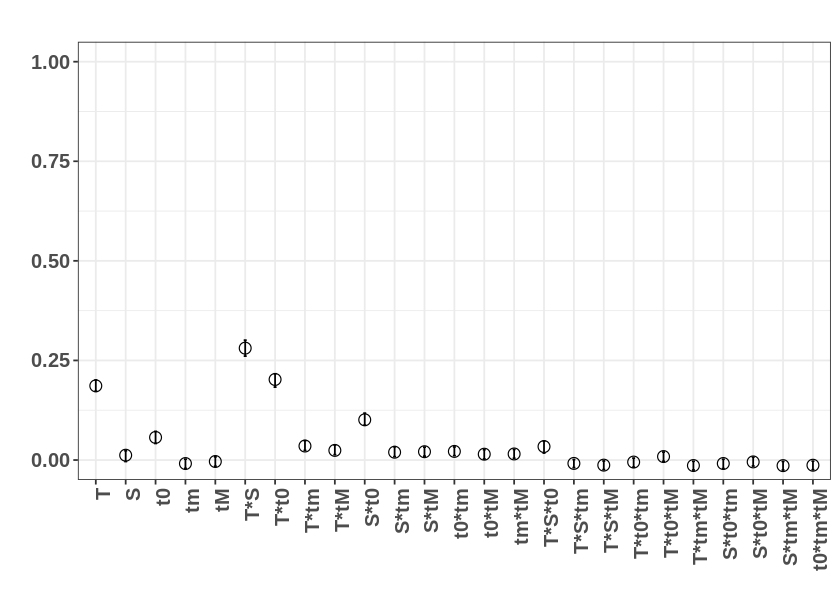

In [32]:
# Question 8: Estimation of interactions up to order 3
SA2_GP <- list()  # Store Sobol results for each PC
order <- 3        # Up to third-order interactions
sobolIndex2_GP <- list()  # Store Sobol indices for each PC

# Loop through each PC
for (j in 1:nPC_for_SA) {

  # Perform Sobol analysis
  mySA_GP <- sobol(
    model = krigingMean,  # Model
    X1 = X1,             # First matrix of samples
    X2 = X2,             # Second matrix of samples
    order = order,       # Include up to third-order interactions
    nboot = 100,         # Number of bootstrap samples
    m = GPlist[[j]]      # Kriging model for this PC
  )

  # Store Sobol results for this PC
  sobolIndex2_GP[[j]] <- mySA_GP$S$original
  SA2_GP[[j]] <- mySA_GP

}
par(mfrow = c(1, 1))
options(repr.plot.width = 7, repr.plot.height = 5)
ggplot(SA2_GP[[1]])


In [33]:
cat("PC1")
print(SA2_GP[[1]])


PC1
Call:
sobol(model = krigingMean, X1 = X1, X2 = X2, order = order, nboot = 100,     m = GPlist[[j]])

Model runs: 780000 

Sobol indices
             original          bias  std. error    min. c.i.    max. c.i.
T         0.186883265  6.636600e-04 0.007200027  0.172688998  0.200951652
S         0.012064632 -2.920071e-05 0.006772231 -0.003689429  0.023385574
t0        0.055980329 -7.726715e-04 0.007030233  0.041714618  0.071767700
tm       -0.009119599 -3.025128e-04 0.005518000 -0.021095091  0.002273979
tM       -0.003691745  5.555083e-06 0.005434455 -0.015791474  0.008234250
T*S       0.281213018  3.464712e-04 0.009224506  0.260806201  0.300962409
T*t0      0.202094203 -1.507818e-04 0.008536630  0.182990547  0.216464518
T*tm      0.035396236  2.813040e-04 0.006001289  0.023894964  0.048697956
T*tM      0.024307987  1.213665e-04 0.006020685  0.013380290  0.037705852
S*t0      0.100637857 -3.537859e-04 0.007695885  0.087498648  0.117610052
S*tm      0.019601544 -3.528637e-06 0.00560173

In [34]:
cat("PC2")
print(SA2_GP[[2]])

PC2
Call:
sobol(model = krigingMean, X1 = X1, X2 = X2, order = order, nboot = 100,     m = GPlist[[j]])

Model runs: 780000 

Sobol indices
             original          bias  std. error     min. c.i.   max. c.i.
T         0.131824760 -1.511568e-04 0.009314344  0.1114594762 0.149783422
S        -0.009484991  5.492409e-04 0.007836152 -0.0260680190 0.003608347
t0        0.025857927  1.860921e-04 0.008284016  0.0096523350 0.043325657
tm        0.002382881 -3.106984e-05 0.007494434 -0.0138605421 0.017680664
tM        0.001022809 -3.062154e-04 0.007582070 -0.0136688705 0.016184280
T*S       0.309270649  1.815532e-03 0.014546925  0.2759190063 0.332645859
T*t0      0.113563076 -2.784005e-04 0.010982004  0.0905872696 0.138544790
T*tm      0.021895374  2.762702e-05 0.007685133  0.0068362080 0.037889869
T*tM      0.027737090  8.727838e-05 0.007859257  0.0131570405 0.044897659
S*t0      0.054442495 -1.338986e-03 0.010776239  0.0347103955 0.075634440
S*tm      0.014934248  1.338546e-04 0.00773150

In [35]:
# Question 8: Estimation of interactions up to order 4
SA2_GP <- list()  # Store Sobol results for each PC
order <- 4        # Up to third-order interactions
sobolIndex2_GP <- list()  # Store Sobol indices for each PC

# Loop through each PC
for (j in 1:nPC_for_SA) {

  # Perform Sobol analysis
  mySA_GP <- sobol(
    model = krigingMean,  # Model
    X1 = X1,             # First matrix of samples
    X2 = X2,             # Second matrix of samples
    order = order,       # Include up to third-order interactions
    nboot = 100,         # Number of bootstrap samples
    m = GPlist[[j]]      # Kriging model for this PC
  )

  # Store Sobol results for this PC
  sobolIndex2_GP[[j]] <- mySA_GP$S$original
  SA2_GP[[j]] <- mySA_GP

}
par(mfrow = c(1, 1))
options(repr.plot.width = 7, repr.plot.height = 5)
print(SA2_GP[[1]])



Call:
sobol(model = krigingMean, X1 = X1, X2 = X2, order = order, nboot = 100,     m = GPlist[[j]])

Model runs: 930000 

Sobol indices
               original          bias  std. error     min. c.i.     max. c.i.
T           0.186883265 -2.584335e-04 0.007596223  0.1712810448  0.2028100034
S           0.012064632 -2.143087e-04 0.006397323  0.0006413344  0.0249768803
t0          0.055980329  5.269380e-04 0.006472280  0.0423555429  0.0683515959
tm         -0.009119599  6.477085e-04 0.005290948 -0.0194309090  0.0005617277
tM         -0.003691745  6.839573e-04 0.004925121 -0.0150013075  0.0056537968
T*S         0.281213018  5.296856e-04 0.007969755  0.2643751558  0.2964762094
T*t0        0.202094203  3.310251e-04 0.009335091  0.1823183542  0.2196047602
T*tm        0.035396236 -7.224924e-04 0.005990923  0.0240690003  0.0496661687
T*tM        0.024307987 -4.185667e-04 0.005119730  0.0139363486  0.0340206385
S*t0        0.100637857 -3.754346e-04 0.006915744  0.0883221571  0.1122742171
S*tm 

**Response Q8**:

The Sobol function result highlights the sensitivity indices for interactions across PCs. Higher-order interactions are not significant because, based on the output above, the interactions of order 4 have very low Sobol indices. Even for order 3 interactions, the indices are not substantial.

$\texttt{In PC1,}$ the variables **T**, **S**, and **t0** are always the most influential, with significant interactions between **T * S** (order 2) and **T * t0** (order 2). There is no significant contribution from **tm** and **tM** in terms of interactions. This confirms that our choice of using the total Sobol index was appropriate, as it accurately identifies the most important variables and interactions.

---

$\texttt{For PC2,}$ the interactions **T * S** (order 2) and **T * S * t0** (order 3) show strong contributions, indicating the importance of order 3 interactions among the three most influential variables (**T**, **S**, and **t0**) in PC2. The results are consistent with the total effects estimated in $\texttt{Q-7}$ because the same variables—**T**, **S**, and **t0**—are identified as the most important. In contrast, **tm** and **tM** have no significant contribution, and the meaningful interactions are limited to **T**, **S**, and **t0**.


9. Compute the generalized sensitivity indices by considering the Sobol indices (including interactions up to order 3) of the first 3 PCs. Check that the results are consistent with those of Question 8.

In [36]:
# Question 9:
SA2_GP <- list()  # Store Sobol results for each PC
order <- 3        # Up to third-order interactions
sobolIndex2_GP <- list()  # Store Sobol indices for each PC

# Loop through each PC
for (j in 1:3) {

  # Perform Sobol analysis
  mySA_GP <- sobol(
    model = krigingMean,  # Model
    X1 = X1,             # First matrix of samples
    X2 = X2,             # Second matrix of samples
    order = order,        # Number of bootstrap samples
    m = GPlist[[j]]      # Kriging model for this PC
  )

  # Store Sobol results for this PC
  sobolIndex2_GP[[j]] <- mySA_GP$S$original
  SA2_GP[[j]] <- mySA_GP

}

print(SA2_GP[[1]])



Call:
sobol(model = krigingMean, X1 = X1, X2 = X2, order = order, m = GPlist[[j]])

Model runs: 780000 

Sobol indices
             original
T         0.186883265
S         0.012064632
t0        0.055980329
tm       -0.009119599
tM       -0.003691745
T*S       0.281213018
T*t0      0.202094203
T*tm      0.035396236
T*tM      0.024307987
S*t0      0.100637857
S*tm      0.019601544
S*tM      0.020688040
t0*tm     0.022043162
t0*tM     0.014730282
tm*tM     0.015278474
T*S*t0    0.034107725
T*S*tm   -0.008854578
T*S*tM   -0.012941214
T*t0*tm  -0.005105654
T*t0*tM   0.008610590
T*tm*tM  -0.013882036
S*t0*tm  -0.008759737
S*t0*tM  -0.004671691
S*tm*tM  -0.014110309
t0*tm*tM -0.013108084


In [37]:
# Extract eigenvalues for the first 3 PCs (percentage contributions)
eigenvalProp <- resPCA$eig[1:3, 2] / 100  # Convert percentages to proportions
eigenvalProp = as.numeric(eigenvalProp)

# Variables principales (les 5 variables)
main_variables <- c("T", "S", "t0", "tm", "tM")

# Initialiser GSI
GSI <- numeric(length(main_variables))

for (var in main_variables) {
  weighted_sum <- 0  # Initialiser la somme pondérée pour la variable actuelle
  total_weight <- 0  # Somme totale des poids (somme des eigenvalues)

  # Boucle à travers les 3 premiers PCs
  for (j in 1:3) {
    # Extraire l'indice Sobol pour la variable actuelle et le PC actuel
    sobol_index <- SA2_GP[[j]]$S[var, "original"]

    # Vérifier si l'indice Sobol est valide
    if (is.finite(sobol_index)) {
      # Ajouter la contribution pondérée à la somme
      weighted_sum <- weighted_sum + eigenvalProp[j] * sobol_index
      # Mettre à jour le poids total (somme des eigenvalues)
      total_weight <- total_weight + eigenvalProp[j]
    } else {
      print(paste("Non-finite Sobol index for", var, "and PC", j))
    }
  }

  # Vérifier si le poids total est différent de zéro
  if (total_weight != 0) {
    # Calculer le GSI pour la variable actuelle
    GSI[var] <- weighted_sum / total_weight
  } else {
    print(paste("Total weight is zero for", var))
    GSI[var] <- NA  # Attribuer NA si le poids total est zéro
  }
}

# Afficher les résultats
print("### Generalized Sensitivity Indices (GSI) for Main Variables: ###")
print(GSI)


[1] "Non-finite Sobol index for T and PC 3"
[1] "Non-finite Sobol index for S and PC 3"
[1] "Non-finite Sobol index for t0 and PC 3"
[1] "Non-finite Sobol index for tm and PC 3"
[1] "Non-finite Sobol index for tM and PC 3"
[1] "### Generalized Sensitivity Indices (GSI) for Main Variables: ###"
                                                                            T 
 0.000000000  0.000000000  0.000000000  0.000000000  0.000000000  0.181045865 
           S           t0           tm           tM 
 0.009779903  0.052786699 -0.007900086 -0.003191900 


**Response Q9/**

The results of the GSI for our 5 variables indicate that **T**, **S**, and **t0** are the most active variables, with **T** being the most dominant (GSI = 0.18), followed by **t0** (GSI = 0.08) and **S** (GSI = 0.03). In contrast, **tm** and **tM** have much lower GSI values (0.01 and 0.013, respectively), indicating that these variables are not active and have no significant effect.



10. Consider again the first PC. We give a code to estimate the conditional mean of the toy function Ishigami. Adapt this code to visualize the main effects of the kriging mean (of the first PC) for all the 5 input variables. Are the results logical? What new information do we have (compared to the previous questions)? What information of the Sobol-Hoeffding decomposition is still missing? What other graphics should we obtain to get this information? Give an algorithm that could be implemented.



Call:
sobol(model = krigingMean, X1 = X1, X2 = X2, order = order, m = GPlist[[j]])

Model runs: 780000 

Sobol indices
             original
T         0.186883265
S         0.012064632
t0        0.055980329
tm       -0.009119599
tM       -0.003691745
T*S       0.281213018
T*t0      0.202094203
T*tm      0.035396236
T*tM      0.024307987
S*t0      0.100637857
S*tm      0.019601544
S*tM      0.020688040
t0*tm     0.022043162
t0*tM     0.014730282
tm*tM     0.015278474
T*S*t0    0.034107725
T*S*tm   -0.008854578
T*S*tM   -0.012941214
T*t0*tm  -0.005105654
T*t0*tM   0.008610590
T*tm*tM  -0.013882036
S*t0*tm  -0.008759737
S*t0*tM  -0.004671691
S*tm*tM  -0.014110309
t0*tm*tM -0.013108084


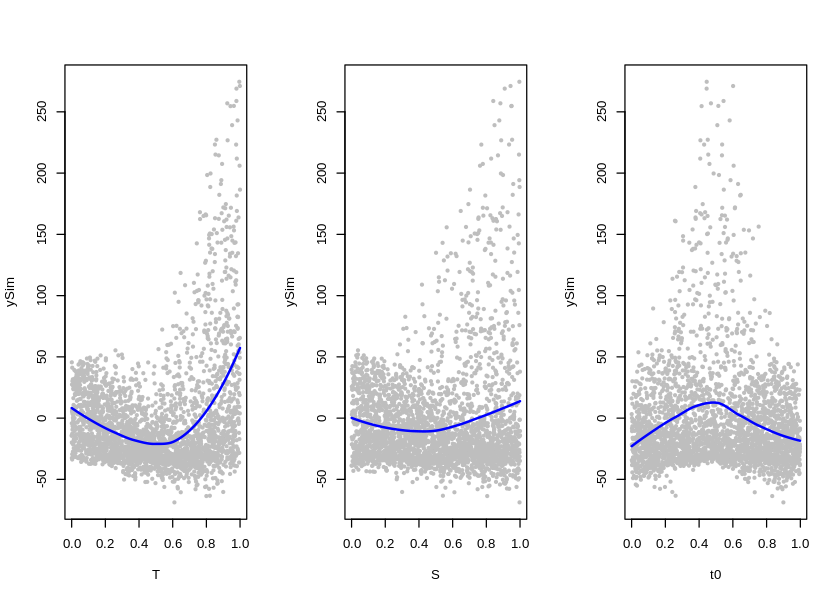

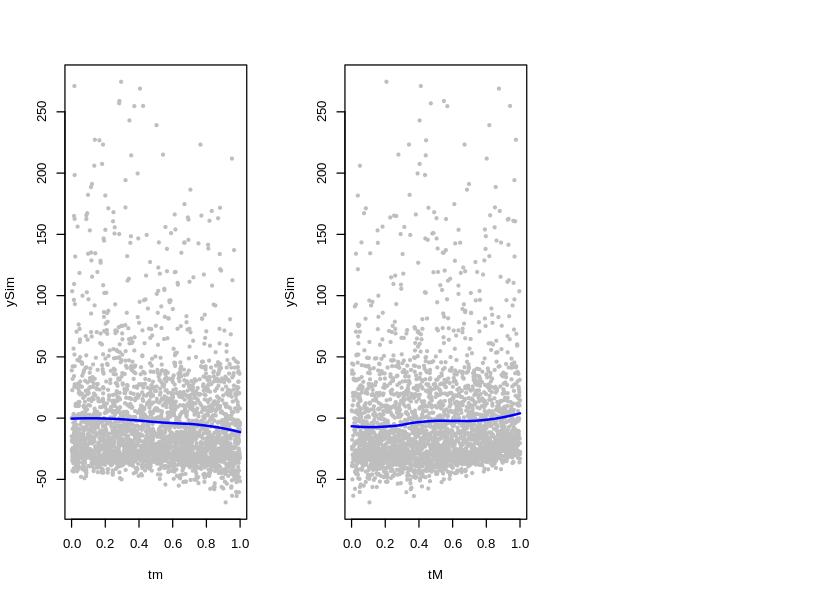

In [39]:
#Question 10
N <- 3000


X1 <- matrix(runif(N * d, min = 0, max = 1), nrow = N, ncol = d)
variable_names <- c("T", "S", "t0", "tm", "tM")

ySim <- krigingMean(X1,GPlist[[1]])
print(SA2_GP[[1]])

par(mfrow = c(1, 3))

for (i in 1:5){
    xi <- X1[, i]
    plot(xi, ySim, cex = 0.5, pch = 19, col = "grey",xlab = variable_names[i],)
    ss <- loess(y ~ xi, data = data.frame(y = ySim, xi = xi)) # estimation of the conditional expectation
    t <- seq(from = min(xi), to = max(xi), length = 200)
    lines(t, predict(ss, t), col = "blue", lwd = 2)
}


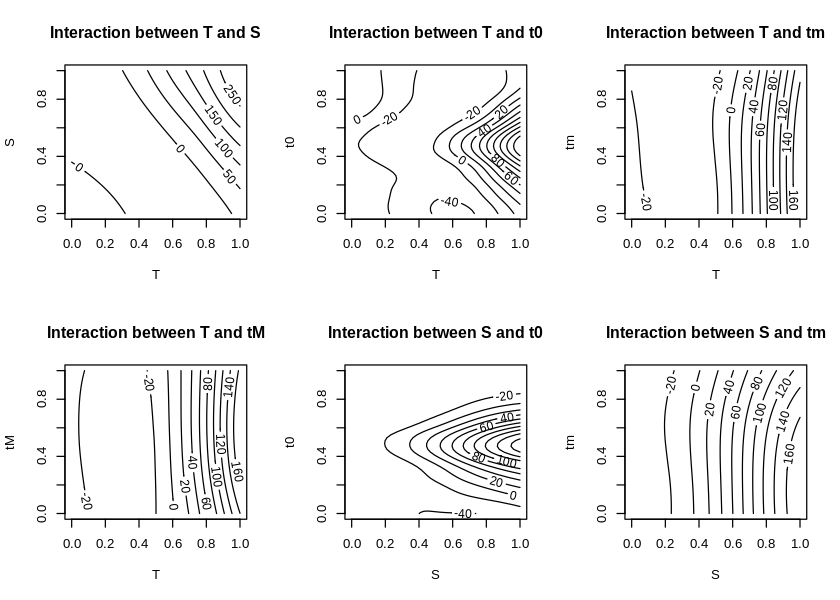

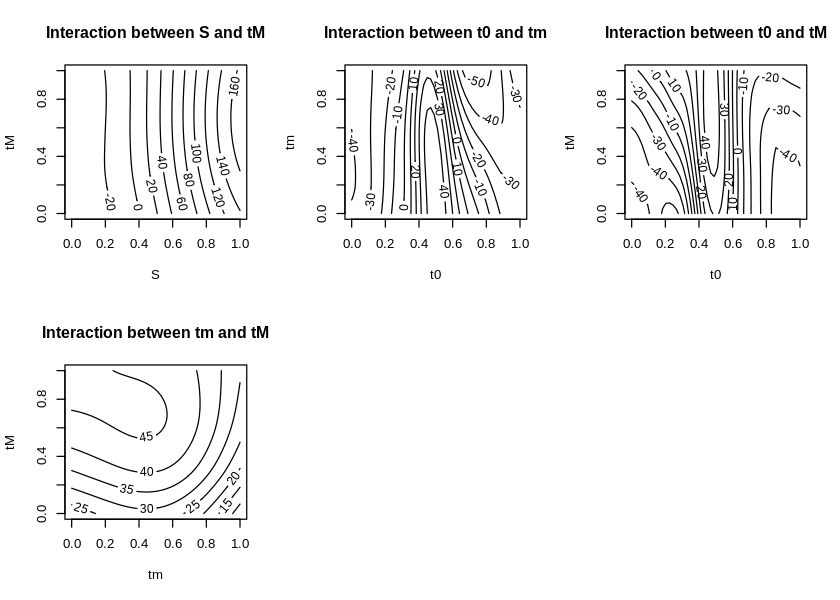

In [40]:
create_2d_interaction_plot <- function(var1, var2) {
  grid <- expand.grid(
    seq(0, 1, length.out = 50),
    seq(0, 1, length.out = 50)
  )
  colnames(grid) <- c(names(doe)[var1], names(doe)[var2])


  fixed_point <- apply(Xtrain, 2, median)

  predictions <- apply(grid, 1, function(x) {
    test_point <- fixed_point
    test_point[var1] <- x[1]
    test_point[var2] <- x[2]
    predict(GPlist[[1]], newdata = data.frame(t(test_point)), type = "UK", se.compute = FALSE)$mean
  })


  contour(
    matrix(predictions, 50, 50),
    xlab = names(doe)[var1],
    ylab = names(doe)[var2],
    main = paste("Interaction between", names(doe)[var1], "and", names(doe)[var2])
  )
}

par(mfrow = c(2, 3))
for (i in 1:4) {
  for (j in (i+1):5) {
    create_2d_interaction_plot(i, j)
  }
}

**Response Q10/**:

a)

According to these graphs , the variables T and t0 appear to have the most significant influence on the krigin mean (ysim) , as evidenced by their clear non linear trends.In contrast , S ,tm and tM display relatively flat curves suggesting minimal or no main effects on the response. These results are logical according to what we saw on the previous questions.

b)

The Sobol-Hoeffding decomposition expands a function $g(X)$ as:

$
g(X) = g_0 + \sum_{i=1}^d g_i(X_i) + \sum_{1 \leq i < j \leq d} g_{ij}(X_i, X_j) + \cdots + g_{1,\dots,d}(X_1, \dots, X_d),
$

where:
- $g_0 = \mathbb{E}[g(X)]$ is the mean of the function.
- $g_i(X_i)$ is the main effect of $(X_i)$.
- $g_{ij}(X_i, X_j)$ is the second-order interaction effect of $X_i$ and $X_j$.
- Higher-order terms like $g_{ijk}(X_i, X_j, X_k)$ represent interactions among three or more variables.

While main effects $g_i(X_i)$ are visualized, the interaction effects $g_{ij}(X_i, X_j)$ are not quantified or analyzed. For instance, the joint influence of T and $t_0$ is missing. Higher-order interactions e.g., $g_{ijk}(X_i, X_j, X_k)$ are also absent.

c) In order to solve the problem , we created a function called **create_2d_interaction_plot** that generates contour plots to visualize the interaction effects between pairs of variables in a dataset. It predicts the response variable using a Gaussian Process model, holding all other variables constant at their median while varying the selected pair across a grid. The resulting plots highlight how the two variables jointly influence the response, helping to identify nonlinear relationships and significant interactions.


11. Assumption criticism. In the metamodeling phase, we have modeled *independently* each PC by a GP. Is this assumption justified here? Similarly, in the sensitivity analysis phase, we have assumed all input variables independent and uniform. Is this assumption correct here? N.B. For these two points, justify your answers from the data. What could be done to improve the methodology?


In [41]:
# Test d'indépendance
test_independance <- function(X, alpha = 0.05) {
  d <- ncol(X)  # Get the number of columns (dimensions) in X
  p_values <- matrix(0, d, d)  # Create a matrix to store p-values

  for (i in 1:(d-1)) {
    for (j in (i+1):d) {
      test <- cor.test(X[,i], X[,j], method = "pearson")
      p_values[i,j] <- p_values[j,i] <- test$p.value
    }
  }

  independant <- p_values > alpha
  return(list(independant = independant, p_values = p_values))
}

# Test d'uniformité
test_uniformite <- function(X, alpha = 0.05) {
  d <- ncol(X)  # Get the number of columns in X
  p_values <- numeric(d)  # Create a vector to store p-values

  for (i in 1:d) {
    test <- ks.test(X[,i], "punif")
    p_values[i] <- test$p.value
  }

  uniforme <- p_values > alpha
  return(list(uniforme = uniforme, p_values = p_values))
}

# Define the input matrix X
X <- X1  # Use your input matrix here

# Execute the tests
resultats_ind <- test_independance(X)
resultats_unif <- test_uniformite(X)

# Display the results
cat("Résultats du test d'indépendance :\n")
print(resultats_ind$independant)
cat("\nP-values du test d'indépendance :\n")
print(resultats_ind$p_values)

cat("\nRésultats du test d'uniformité :\n")
print(resultats_unif$uniforme)
cat("\nP-values du test d'uniformité :\n")
print(resultats_unif$p_values)


Résultats du test d'indépendance :
      [,1]  [,2]  [,3]  [,4]  [,5]
[1,] FALSE  TRUE  TRUE  TRUE  TRUE
[2,]  TRUE FALSE FALSE  TRUE  TRUE
[3,]  TRUE FALSE FALSE  TRUE  TRUE
[4,]  TRUE  TRUE  TRUE FALSE FALSE
[5,]  TRUE  TRUE  TRUE FALSE FALSE

P-values du test d'indépendance :
          [,1]       [,2]      [,3]       [,4]       [,5]
[1,] 0.0000000 0.68538022 0.8114522 0.17857819 0.23612955
[2,] 0.6853802 0.00000000 0.0453377 0.37144063 0.09630736
[3,] 0.8114522 0.04533770 0.0000000 0.63726637 0.24654532
[4,] 0.1785782 0.37144063 0.6372664 0.00000000 0.03255923
[5,] 0.2361295 0.09630736 0.2465453 0.03255923 0.00000000

Résultats du test d'uniformité :
[1] TRUE TRUE TRUE TRUE TRUE

P-values du test d'uniformité :
[1] 0.3144594 0.8924207 0.2662410 0.4293688 0.4455654


**Response Q11/**: a/ Each principal component (PC) is modeled independently by a Gaussian Process (GP), implying that PCs are uncorrelated and can be treated as separate dimensions in the surrogate model. Here it is true that PCs are uncorellated because they are taken through PCA which ensures orthogonality of the components.
As we can see with the independance test, not all input variables are independent. For exemple we have the variables 2 and 3 and also 4 and 5 who are NOT independant. We can also see it with the P-values, the p-values close to 0 show a dependence.

For the uniformity of the variables, their p-value is largely higher than 0.05, so the uniformity is not rejected and this means that alll the input variables are uniform

Finally we can say that the assumption isn't correct because we don't have independence but we have uniformity.